In [1]:
import sys

import vis_plotting as vis_plt
import EAVILS_processing
import my_utils
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import matplotlib_venn 
from matplotlib.patches import Circle


import scipy
import os
import yaml
import copy
import pandas as pd
import bidict

import astropy.io.fits as fits
from astropy.coordinates import Angle
from astropy import units as u
from astropy.time import Time



In [16]:
#For now this is still necessary to handle pointing information. In future versions this should be contained as metadata in h5 files
metafits_folder = '/Volumes/Data4/elillesk/data_and_analysis/uvfits/chisq_obs/'

#Flagging the coarse band lines for the MWA. In general this parameter can be used for flagging coarse-band lines,
#or things like known FM or satellite contaminated channels
permanent_flags = my_utils.coarse_band_flagging()

#This shape_dict is taken from SSINS, with an additional "subTV" pseudo-channel added as a control "clean channel". 
#This subTV channel is quite simply the frequencies below which the digital TV channels live
shape_dict = my_utils.shape_dict('MWA',add_subTV=True)
#We only want TV channels, so we remove the 'center_packet_loss' frequency type
del shape_dict['center_packet_loss']
print(shape_dict)
#This quite simply sorts our frequency channels based on their minimum frequency
sorted_freq_ranges,sorted_freq_mins = EAVILS_processing.freq_range_sort(shape_dict)
#Establishes the correspondence between polarizations and polarization indices
pol_bidict = bidict.bidict({0:'XX',1:'YY',2:'XY',3:'YX'})


{'TV6': [174000000.0, 181000000.0], 'TV7': [181000000.0, 188000000.0], 'TV8': [188000000.0, 195000000.0], 'TV9': [195000000.0, 202000000.0], 'subTV': [167075000.0, 174000000.0]}


In [3]:
#input_directory = 'testing_tutorial/h5_files/'
input_directory = '/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files/'

In [6]:
list_file_directory = 'example_obs_lists'

In [7]:
print(os.listdir(list_file_directory))

['11-17-2016-EOR0.txt', '10-30-2016-EOR0.txt', '10-30-2016-EOR1.txt', '12-15-2016-EOR0.txt', '10-19-2016-EOR1.txt', '10-19-2016-EOR0.txt', '10-17-2016-EOR1.txt', '10-17-2016-EOR0.txt', '11-19-2016-EOR0.txt', '10-15-2016-EOR0.txt', '10-28-2016-EOR1.txt', '10-28-2016-EOR0.txt', '10-15-2016-EOR1.txt', '11-21-2016-EOR0.txt', '.ipynb_checkpoints', '10-21-2016-EOR0.txt', '10-21-2016-EOR1.txt', '10-22-2016-EOR0.txt', '11-12-2016-EOR0.txt', '10-26-2016-EOR1.txt', '10-26-2016-EOR0.txt', '10-22-2016-EOR1.txt']


In [8]:
EOR0_lists = []
EOR1_lists = []
for file in os.listdir(list_file_directory):
    if 'EOR0' in file:
        EOR0_lists.append(file)
    elif 'EOR1' in file:
        EOR1_lists.append(file)

In [9]:
#Sets the time and frequency dimensions of the coarse-graining. 
#When the number of times or frequencies doesn't divide evenly by 
time_dim = 8
freq_dim = 1

In [10]:
import importlib

In [11]:
importlib.reload(EAVILS_processing)

<module 'EAVILS_processing' from '/Users/elillesk/repos/SSINS/EAVILS/EAVILS_processing.py'>

In [18]:

all_lists =  EOR0_lists+EOR1_lists

all_lists = sorted(all_lists)
for list_file in all_lists:
    
    list_title=list_file.split('.txt')[0]
    list_file = f'{list_file_directory}/{list_file}'
    print(list_title, list_file)
    EAVILS_processing.process_data(list_file=list_file,
                                   input_directory=input_directory,
                                   output_directory='testing_tutorial',
                                   time_dim=time_dim,
                                   freq_dim=freq_dim,
                                   pol_bidict=pol_bidict,
                                   shape_dict=shape_dict,
                                   permanent_flags=permanent_flags,
                                   metafits_folder=metafits_folder,
                                   pre_flag_on_SSINS_masks=True,
                                   clobber=False, 
                                   allowed_missing_fraction=0.1)

10-15-2016-EOR0 example_obs_lists/10-15-2016-EOR0.txt
Output file testing_tutorial/10-15-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-15-2016-EOR1 example_obs_lists/10-15-2016-EOR1.txt
Output file testing_tutorial/10-15-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-17-2016-EOR0 example_obs_lists/10-17-2016-EOR0.txt
Output file testing_tutorial/10-17-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-17-2016-EOR1 example_obs_lists/10-17-2016-EOR1.txt
Output file testing_tutorial/10-17-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-19-2016-EOR0 example_obs_lists/10-19-2016-EOR0.txt
Output file testing_tutorial/10-19-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already e

In [19]:
processed_data_directory = 'testing_tutorial/'
list_titles = [file.split('.')[0] for file in os.listdir(list_file_directory) if len(file.split('.')[0] )>0]
list_titles = sorted(list_titles)
sky_field_list = ['EOR0','EOR1']
sky_field_list_association = {list_file.split('.')[0]:'EOR0' for list_file in EOR0_lists}
sky_field_list_association.update({list_file.split('.')[0]:'EOR1' for list_file in EOR1_lists})

In [20]:
#Establishes the order in which polarizations should be subtracted
pol_subtraction_order = {(0,1),(1,0),(2,3),(3,2)}

In [21]:
importlib.reload(EAVILS_processing)
array_dict, dof_ref_dict,sky_field_dict,source_list_dict,pointing_info_dict = EAVILS_processing.create_data_arrays(processed_data_directory = processed_data_directory,list_titles=list_titles, time_dim=time_dim,freq_dim=freq_dim, shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pol_subtraction_order=pol_subtraction_order)

creating data arrays
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0


In [22]:
importlib.reload(EAVILS_processing)
datafr = EAVILS_processing.create_data_frame(pol_bidict=pol_bidict,
                                             shape_dict=shape_dict,
                                             array_dict=array_dict,
                                             sky_field_dict=sky_field_dict,
                                             source_list_dict=source_list_dict,
                                             pointing_info_dict=pointing_info_dict)

In [23]:
cows_df = pd.read_csv("testing_tutorial/all_processed_cows_data.csv")
cows_df['non cow EAVILS event '] = cows_df['non cow EAVILS event '].fillna(0)

cows_df['Obsid'] = cows_df['Obsid'].astype(str)
times = ['11:00',
 '12:00',
 '13:00',
 '14:00',
 '15:00',
 '16:00',
 '17:00',
 '18:00',
 '19:00',
 '20:00']


mjds = []
for time in cows_df["Obsid"]:
    mjds.append(Time(time, format="gps").mjd)

cows_df["mjd"] = mjds

int_mjds = [np.floor(i) for i in mjds]
days = Time(int_mjds, format='mjd')
obsids = np.array(cows_df["Obsid"])

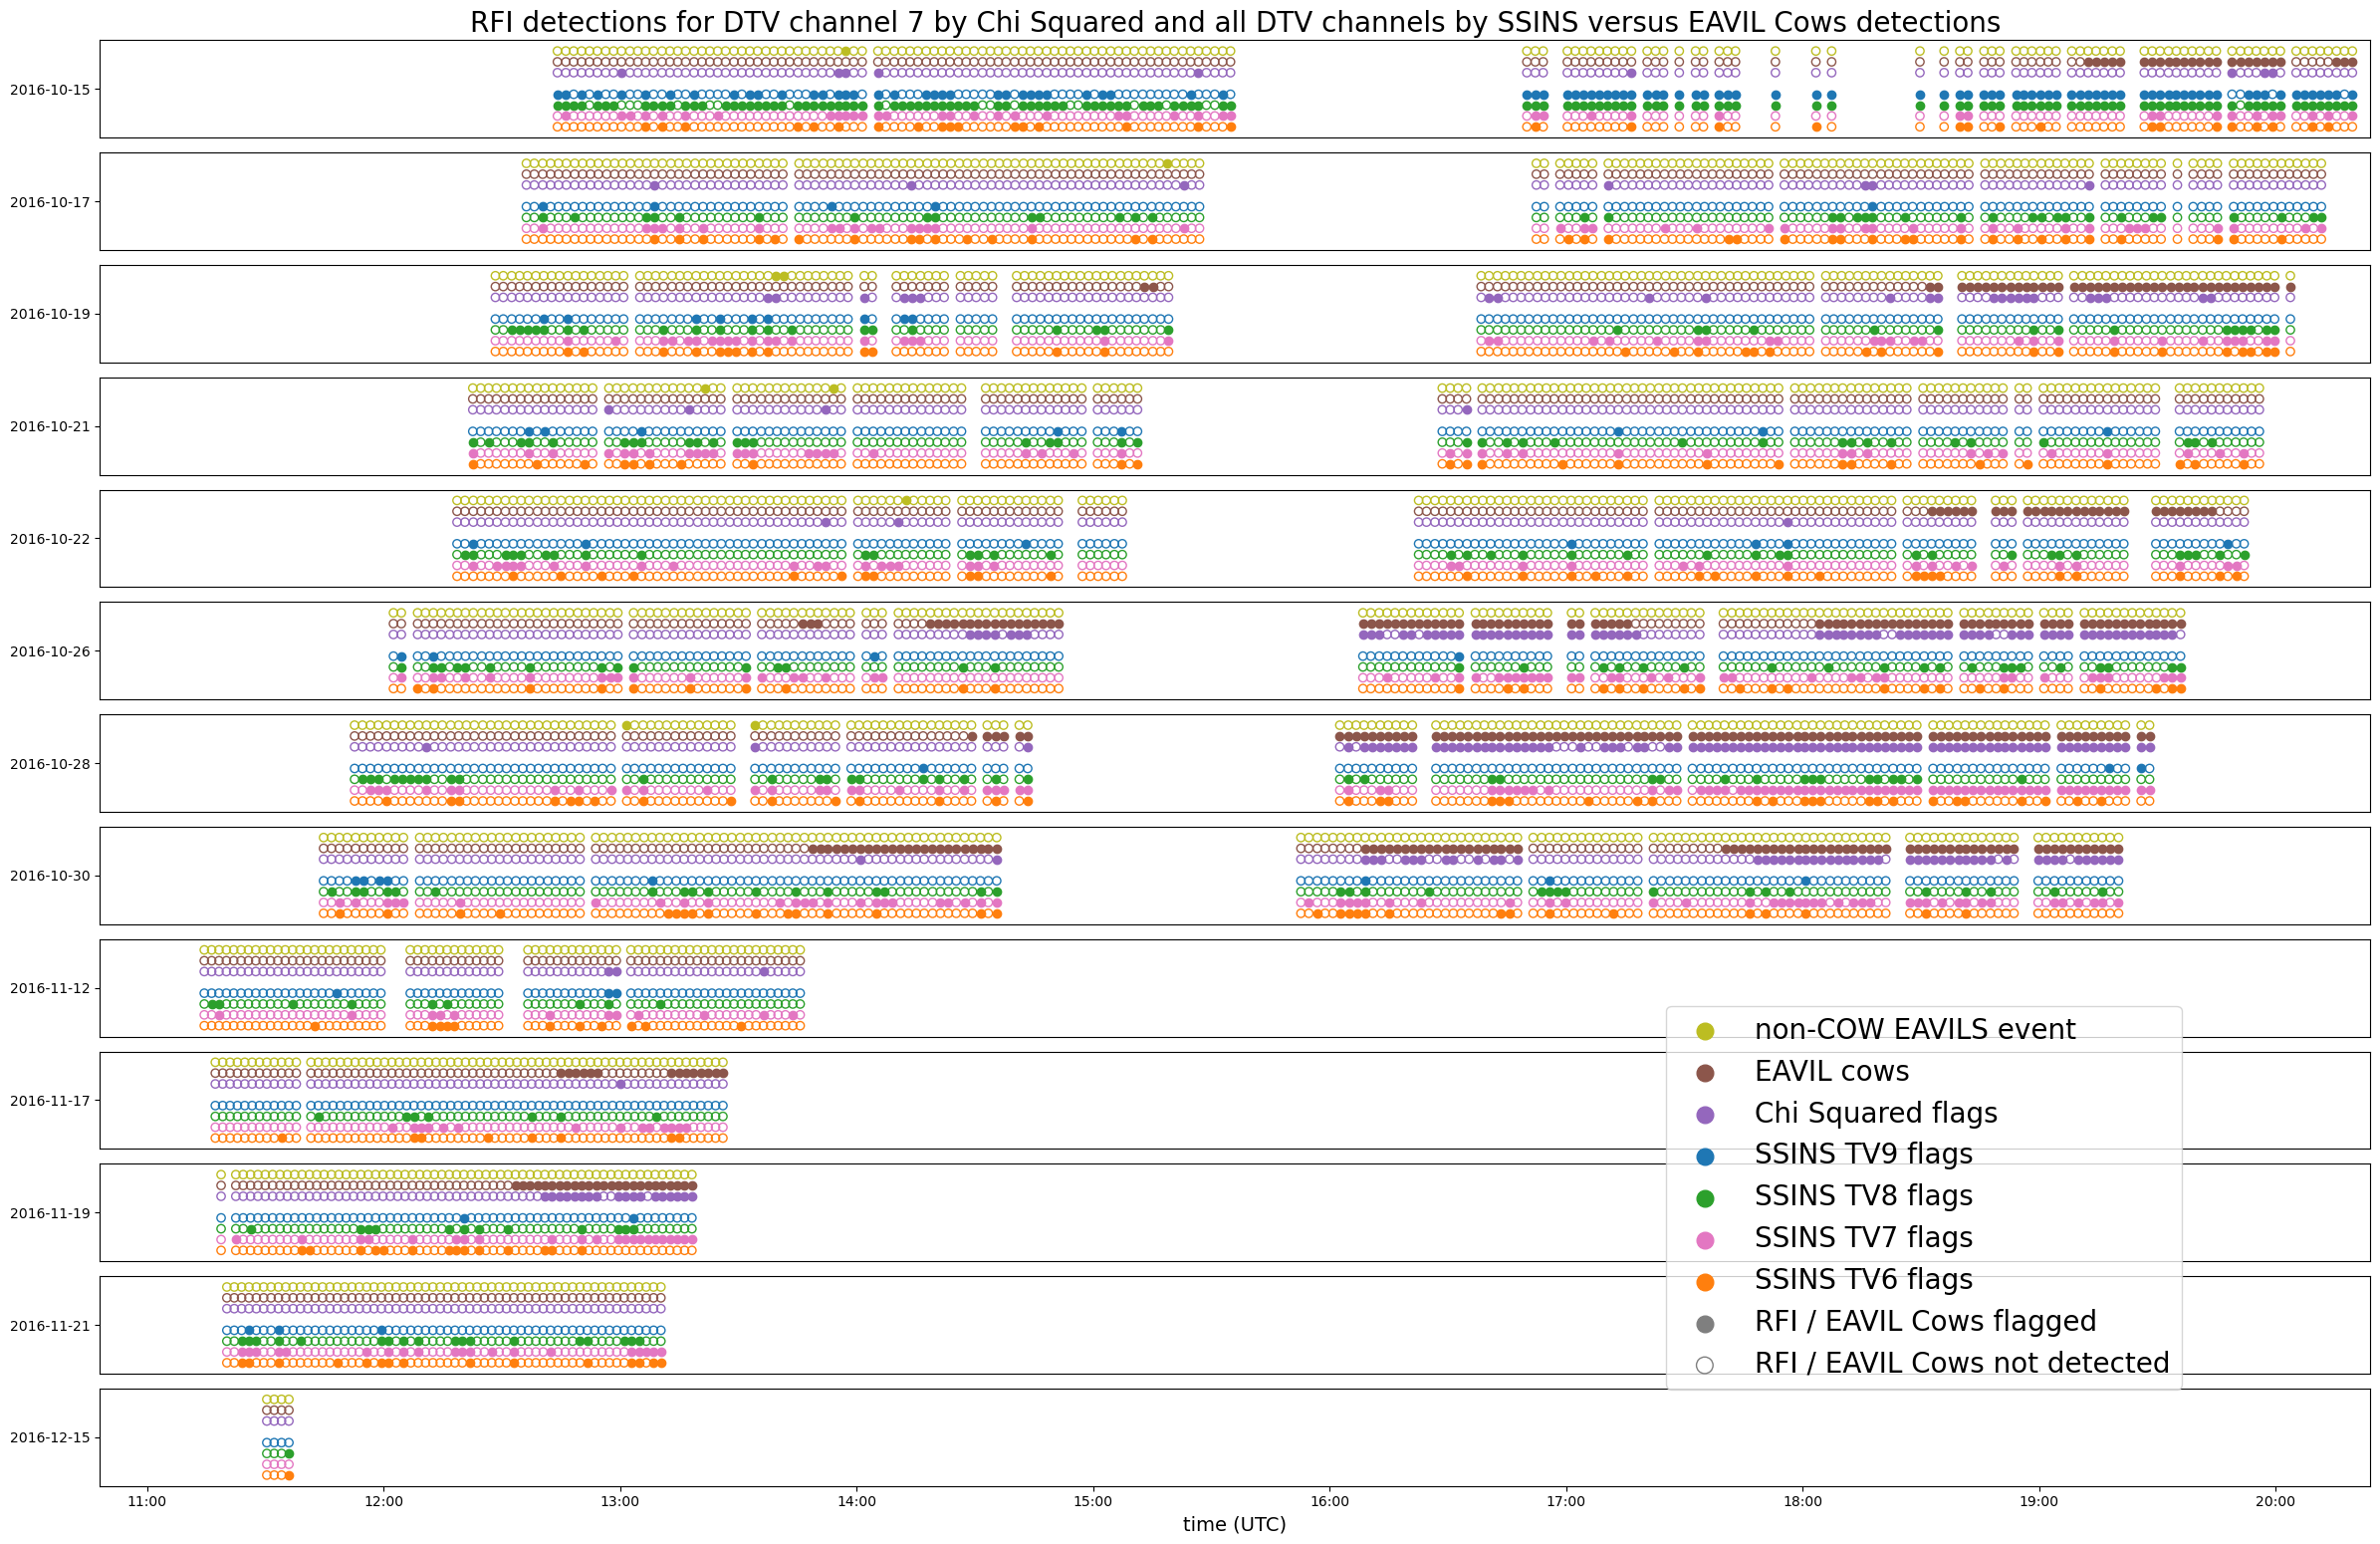

In [24]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*1.2))


if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}
       
        ssins_tv9_kwargs = {'facecolors':'none', 'edgecolors':'tab:blue'}
        ssins_tv8_kwargs = {'facecolors':'none', 'edgecolors':'tab:green'}
        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        ssins_tv6_kwargs = {'facecolors':'none', 'edgecolors':'tab:orange'}

        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'

        if cows_df.loc[:, "SSINS TV9 flags"][index] != 0:
            ssins_tv9_kwargs['facecolors'] = 'tab:blue'

        if cows_df.loc[:, "SSINS TV8 flags"][index]  != 0:
            ssins_tv8_kwargs['facecolors'] = 'tab:green'

        if cows_df.loc[:, "SSINS TV7 flags"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'

        if cows_df.loc[:, "SSINS TV6 flags"][index]  != 0:
            ssins_tv6_kwargs['facecolors'] = 'tab:orange'

           
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.7, **non_cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.6, **cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.5, **chisq_kwargs) # chisq

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **ssins_tv9_kwargs) # ssins tv9
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **ssins_tv8_kwargs) # ssins tv8
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **ssins_tv7_kwargs) # ssins tv7
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y, **ssins_tv6_kwargs) # ssins tv6
    ax[i].set_ylim(0.8, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]])
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times)
plt.xlabel('time (UTC)', fontsize=14)

ax[0].set_title('RFI detections for DTV channel 7 by Chi Squared and all DTV channels by SSINS versus EAVIL Cows detections', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='EAVIL cows')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared flags')

ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 flags')
ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[non_cows_dot,cows_dot, chisq_dot, ssins_tv9_dot, ssins_tv8_dot, ssins_tv7_dot, ssins_tv6_dot, filled_dot, empty_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
# fig.savefig("eavil_cows_dotplot_updated.pdf")

In [25]:
good_source_dict = {'EOR0':'10-17-2016-EOR0','EOR1':'10-17-2016-EOR1'}


In [26]:
non_cow_EAVILS_obs_list = cows_df['Obsid'][cows_df['non cow EAVILS event ']==True].astype(str)
non_cow_EAVILS_obs_list

36      1160575016
232     1160752712
362     1160919552
363     1160919672
531     1161091272
546     1161093224
732     1161180728
1059    1161694880
1073    1161696832
Name: Obsid, dtype: object

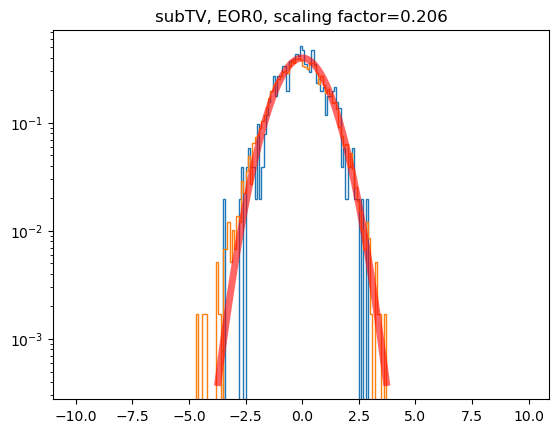

subTV 0.20642177600773748


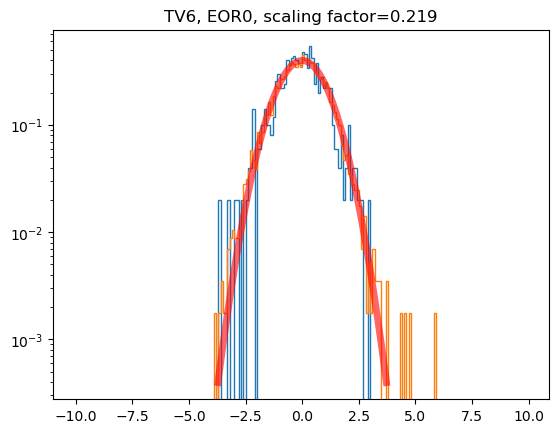

TV6 0.21888826618972923


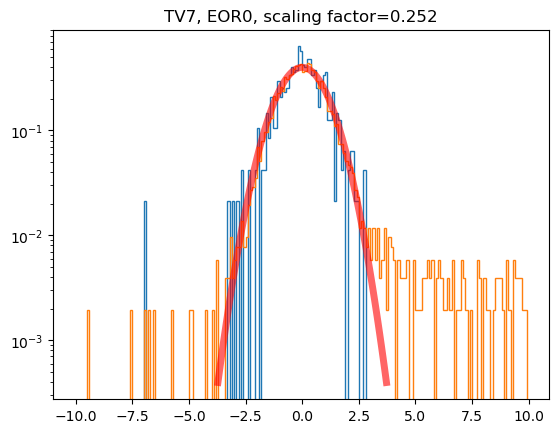

TV7 0.25237745580544174


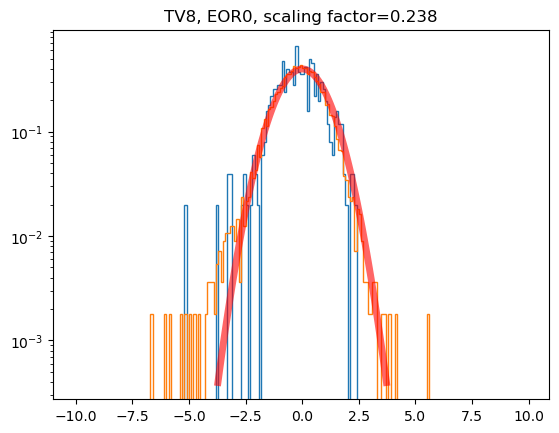

TV8 0.23768252002210125


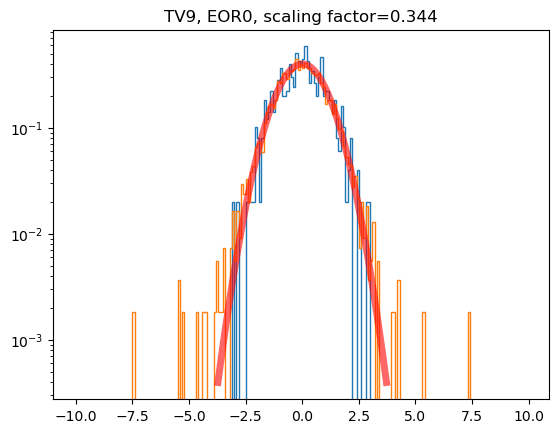

TV9 0.34433548513618567


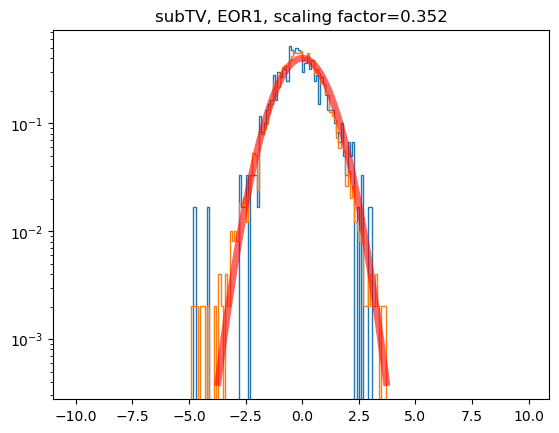

subTV 0.3517692235879413


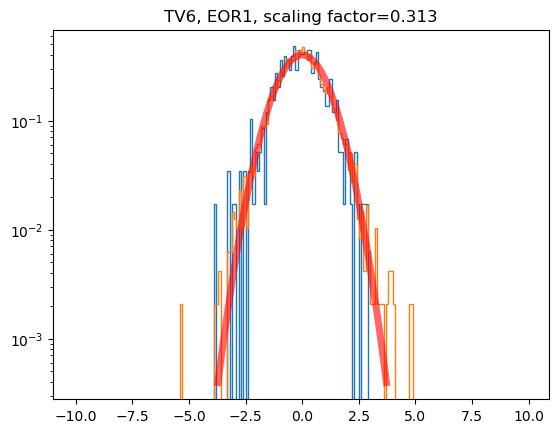

TV6 0.3131892011272576


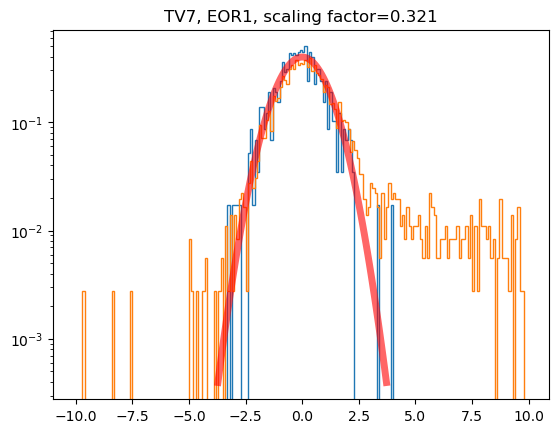

TV7 0.32103032783427293


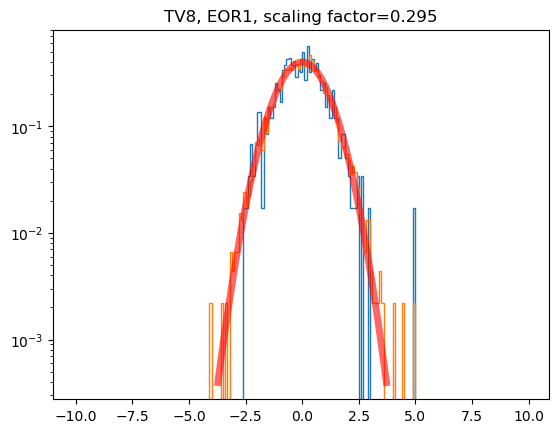

TV8 0.29514659355796546


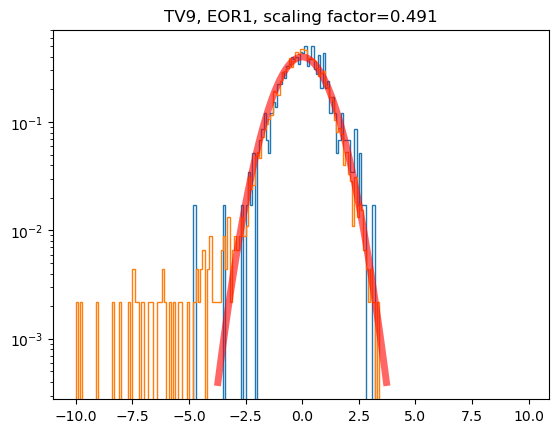

TV9 0.4914488492397479


In [27]:
initial_estimated_pol_sub_stdv= {sky_field:{} for sky_field in sky_field_list}



for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        
        good_source_list = good_source_dict[sky_field]
        query_string_clean = f'source_list==\'{good_source_list}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
        
        pol_sub_series_clean = datafr[~datafr['obs_id'].isin(non_cow_EAVILS_obs_list)].query(query_string_clean)['pol_sub']

        scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
        
        initial_estimated_pol_sub_stdv[sky_field][freq_range] = scaling

        
        pol_sub_series = datafr.query(f'{'sky_field'}==\'{sky_field}\' & {'freq_range'}==\'{freq_range}\' & {'SSINS_flagged'}=={False}')['pol_sub']
        channel_dof = dof_ref_dict[freq_range]
       
    
        plt.yscale('log')
        
        plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        
        plt.hist((pol_sub_series)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                    scipy.stats.norm.ppf(0.9999,scale=1), 100)
        plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                'r-', lw=5, alpha=0.6, label='standard normal pdf')
        plt.title(f'{freq_range}, {sky_field}, scaling factor={np.round(scaling,3)}')
        plt.show()
        print(freq_range,scaling)

In [28]:
initial_estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.20642177600773748,
  'TV6': 0.21888826618972923,
  'TV7': 0.25237745580544174,
  'TV8': 0.23768252002210125,
  'TV9': 0.34433548513618567},
 'EOR1': {'subTV': 0.3517692235879413,
  'TV6': 0.3131892011272576,
  'TV7': 0.32103032783427293,
  'TV8': 0.29514659355796546,
  'TV9': 0.4914488492397479}}

## Here we establish a threshold for flagging
 on some simple assumptions on what we want our 

In [29]:
scipy.stats.norm.isf(.001/(5*100)) #False positive rate/(num_freq_channels * approx number of meas. per pointing)

4.611382362302668

In [30]:
threshold = 4.61

iterations: 0
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0
EOR0 subTV estimate shifted by 0.015459590501006093
EOR0 TV6 estimate shifted by 0.00515761030829559
EOR0 TV7 estimate shifted by -0.01018631534661485
EOR0 TV8 estimate shifted by -0.003229706664083287
EOR0 TV9 estimate shifted by 0.016287202367314735
EOR1 subTV estimate shifted by -0.02431863408883067
EOR1 TV6 estimate shifted by 0.004392408392237146
EOR1 TV7 estimate shifted by 0.01115896988197912
EOR1 TV8 estimate shifted by 0.0026948310092055894
EOR1 TV9 estimate shifted by -0.033444162858561666
{'EOR0': {'subTV': 0.22188136650874357, 'TV6': 0.22404587649802482, 'TV7': 0.2421911404588269, 'TV8': 0.23445281335801796, 'TV9': 0.3606226875035

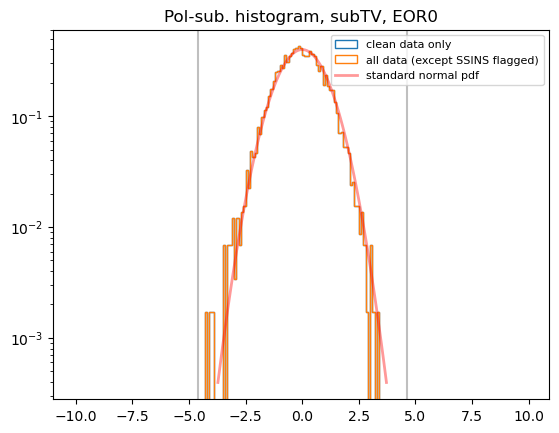

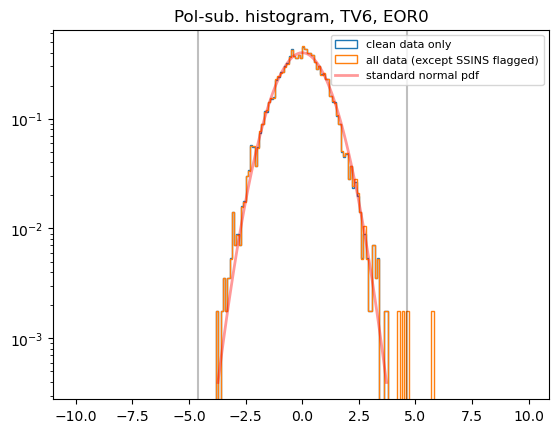

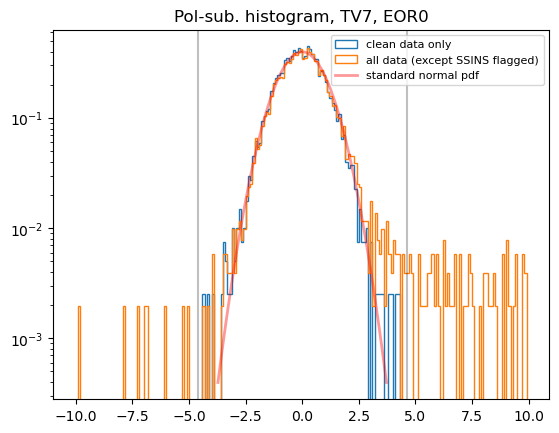

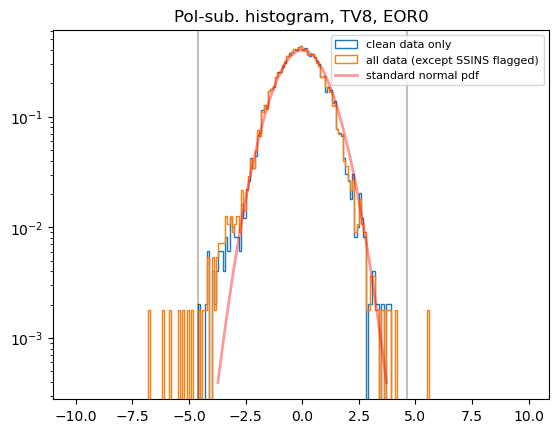

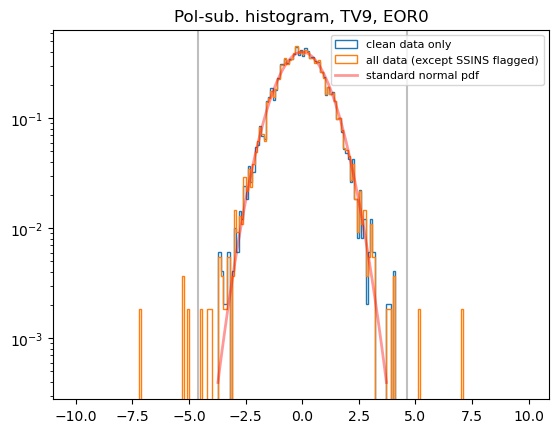

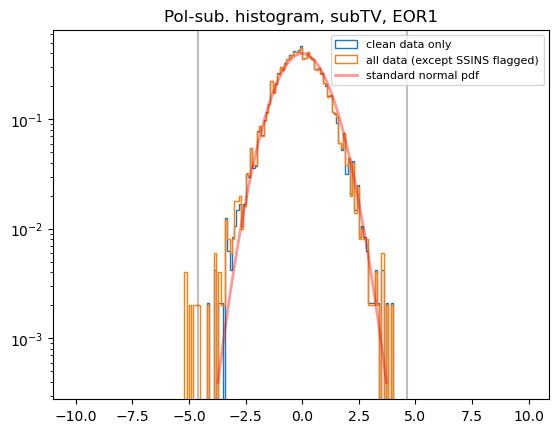

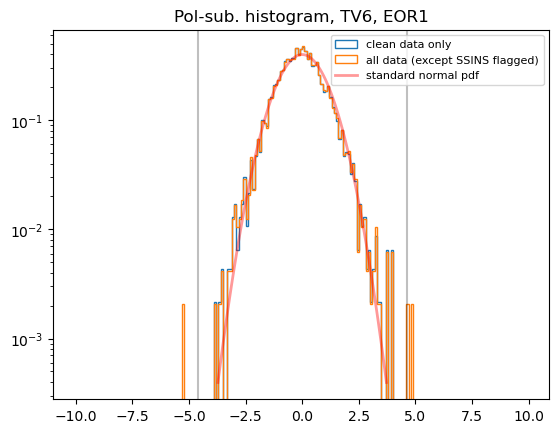

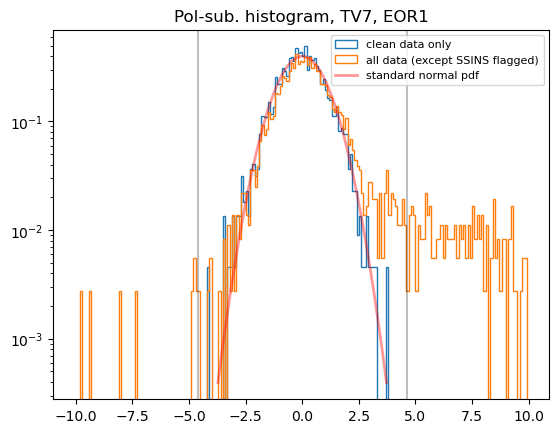

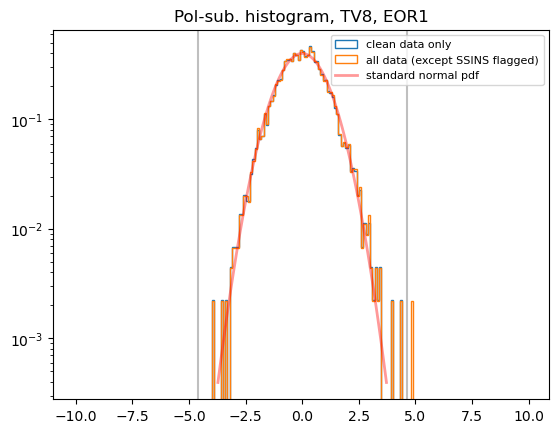

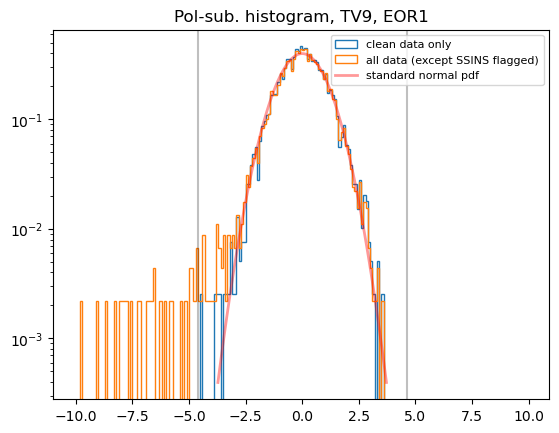

In [31]:
iteration_count=0

datafr['pointing_flagged'] = False #This should already be true, but ensures it's the case

estimated_pol_sub_stdv = copy.deepcopy(initial_estimated_pol_sub_stdv)
while True:
    print('iterations:',iteration_count)
    prev_estimated_pol_sub_stdv = copy.deepcopy(estimated_pol_sub_stdv)
    
    for source_list in np.unique(datafr.source_list):
        print(source_list)
        sky_field = sky_field_list_association[source_list]

        for pointing in np.unique(datafr.pointing):
            for freq_range in sorted_freq_ranges:
                query_string = f'sky_field==\'{sky_field}\' & source_list==\'{source_list}\' & pointing=={pointing} & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                sub_series = datafr.query(query_string)['pol_sub']
                estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
                outliers = np.abs(sub_series)>(estimated_stdv*threshold)
    
                if np.sum(outliers)>0:
                    flag_pointing=True
                else:
                    flag_pointing=False
                if flag_pointing:
                    flagged_indices = datafr.query(query_string).index
                    datafr.loc[flagged_indices,'pointing_flagged'] = True
    
    
    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
            pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
    
            scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
            
            estimated_pol_sub_stdv[sky_field][freq_range] = scaling

    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            print(sky_field,freq_range,'estimate shifted by', estimated_pol_sub_stdv[sky_field][freq_range] - prev_estimated_pol_sub_stdv[sky_field][freq_range])
    print(estimated_pol_sub_stdv) 
    if estimated_pol_sub_stdv==prev_estimated_pol_sub_stdv:    
        for sky_field in sky_field_list:
            for freq_range in sorted_freq_ranges:
                query_string_all = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                pol_sub_series_all = datafr.query(query_string_all)['pol_sub']
                
                query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
                pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
                plt.yscale('log')
                
                scaling = estimated_pol_sub_stdv[sky_field][freq_range]
                
                plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='clean data only')
                plt.hist((pol_sub_series_all)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')
                plt.vlines([-threshold,threshold],ymin=0,ymax=1,color='black',alpha=.25)
                
                x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                            scipy.stats.norm.ppf(0.9999,scale=1), 100)
                plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                        'r-', lw=2, alpha=0.4, label='standard normal pdf')
                plt.title(f'Pol-sub. histogram, {freq_range}, {sky_field}')
                plt.legend( prop={'size': 8})
                plt.show()
        break
    iteration_count+=1
           

In [32]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.22188136650874357,
  'TV6': 0.22404587649802482,
  'TV7': 0.2421911404588269,
  'TV8': 0.23445281335801796,
  'TV9': 0.3606226875035004},
 'EOR1': {'subTV': 0.32745058949911066,
  'TV6': 0.31758160951949477,
  'TV7': 0.33218929771625205,
  'TV8': 0.29784142456717105,
  'TV9': 0.4567150812528031}}

In [33]:
flagged_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
flagged_no_SSINS_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
SSINS_flagged_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
SSINS_majority_obs_ids = {freq_range:[] for freq_range in sorted_freq_ranges}

for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        query_string = f'sky_field==\'{sky_field}\'   & freq_range==\'{freq_range}\''
        
        for include_SSINS_flagged_data in [True,False]:
            if include_SSINS_flagged_data:
                query_mod = ''
            else:
                query_mod = '& SSINS_flagged==False'
            sub_series = datafr.query(query_string+query_mod)['pol_sub']
            estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
            outliers = np.abs(sub_series)>(estimated_stdv*threshold)
            if include_SSINS_flagged_data:
                flagged_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+query_mod)[outliers==True]['obs_id']))
            else:
                flagged_no_SSINS_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+query_mod)[outliers==True]['obs_id']))
        
        
        SSINS_flagged_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+'& SSINS_flagged==True')['obs_id']))

        
        SSINS_flag_counts = datafr.query(query_string+'& SSINS_flagged==True')['obs_id'].value_counts()
        SSINS_majority_obs_ids[freq_range]+=SSINS_flag_counts[SSINS_flag_counts>3].index.tolist()

In [34]:

for freq_range in sorted_freq_ranges:
    cows_df[f'pol_sub_flagged_{freq_range}']=False
    flagged_list = flagged_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(flagged_list),f'pol_sub_flagged_{freq_range}']=True

    cows_df[f'pol_sub_flagged_no_SSINS_{freq_range}']=False
    flagged_no_SSINS_list = flagged_no_SSINS_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(flagged_no_SSINS_list),f'pol_sub_flagged_no_SSINS_{freq_range}']=True
    
    cows_df[f'better_SSINS_flagged_{freq_range}']=False
    SSINS_flagged_list = SSINS_flagged_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(SSINS_flagged_list),f'better_SSINS_flagged_{freq_range}']=True

    cows_df[f'SSINS_majority_flagged_{freq_range}']=False
    SSINS_majority_list = SSINS_majority_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(SSINS_majority_list),f'SSINS_majority_flagged_{freq_range}']=True

In [35]:
def percentage_formatter(subset_size, total_elements):
    if subset_size>0:
        percentage = (subset_size / total_elements) * 100
        return f"\n{subset_size}\n{percentage:.1f}%" # Format as raw_count (percentage%)
    else:
        return ""
        

In [36]:
len(cows_df)

1653

0.8037825059101655

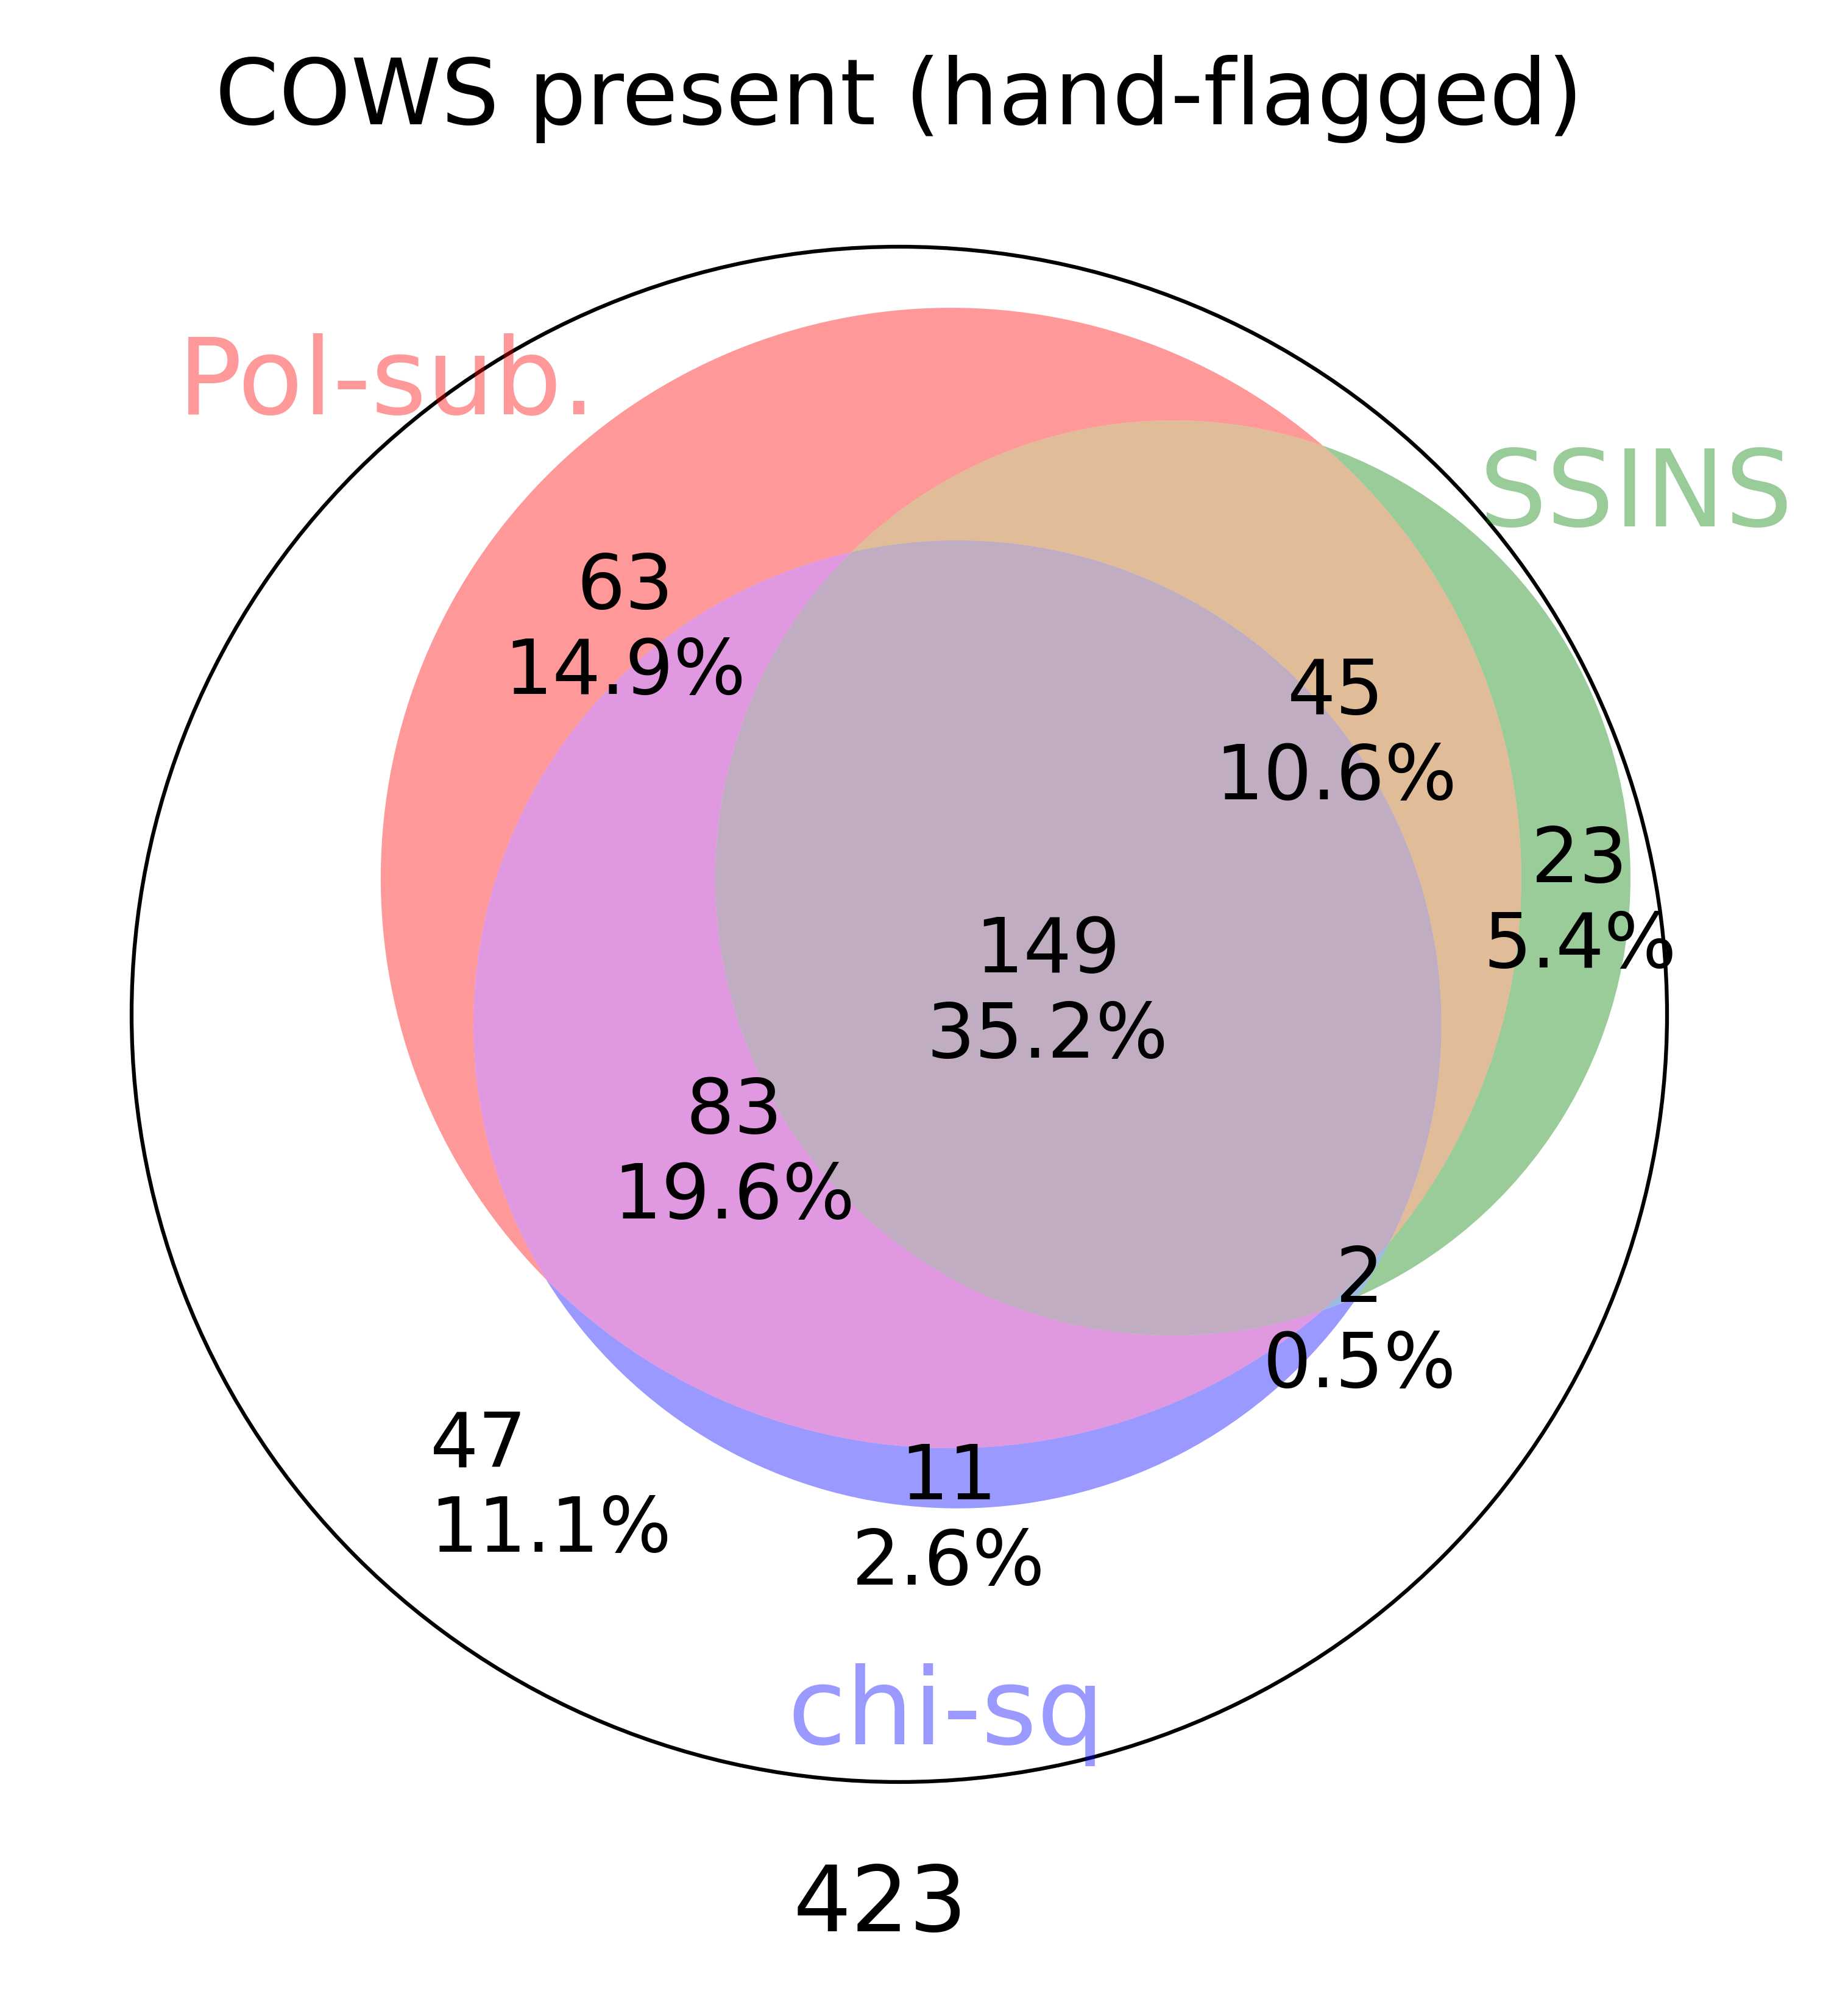

In [59]:

cows_df_local = copy.deepcopy(cows_df[cows_df['COWS']==True])
freq_range = 'TV7'
pol_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'pol_sub_flagged_{freq_range}']==True])
SSINS_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'better_SSINS_flagged_{freq_range}']==True])
chisq_set = set(cows_df_local['Obsid'][cows_df_local[f'CHISQ']==True])
total_union =len(pol_flagged_set.union(SSINS_flagged_set.union(chisq_set)))
grand_total = len(cows_df_local)
remaining = grand_total-total_union
plt.figure(figsize=(4,4),dpi=900)
out = matplotlib_venn.venn3([pol_flagged_set, SSINS_flagged_set, chisq_set], set_labels = ('Pol-sub.', 'SSINS', 'chi-sq'),
        subset_label_formatter=lambda x: percentage_formatter(x, grand_total))

number_label_size = 10
for text in out.subset_labels:
    text.set_fontsize(number_label_size)


ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

center_x = (xlim[0] + xlim[1]) / 2
center_y = (ylim[0] + ylim[1]) / 2
radius = (max(xlim[1] - xlim[0], ylim[1] - ylim[0]) / 2 )* 1.05
center_adjust = (-.1,-.1)
circle = Circle((center_x+center_adjust[0], center_y+center_adjust[1]), radius, fill=False, color='black', linewidth=.5)
ax.add_patch(circle)
ax.set_xlim(center_x+center_adjust[0] - radius * 1.1, center_x+center_adjust[0] + radius * 1.1)
ax.set_ylim(center_y+center_adjust[1] - radius * 1.1, center_y+center_adjust[1] + radius * 1.1)


label_x = center_x - radius * 0.75
label_y = center_y - radius * 0.7
ax.text(label_x, label_y, percentage_formatter(remaining,grand_total), fontsize=number_label_size, ha='left', va='center')

label_x = center_x -.2
label_y = center_y - radius * 1.3
ax.text(label_x, label_y, grand_total, fontsize=12, ha='left', va='center')


plt.title('COWS present (hand-flagged)',size=12)
color_list = []
for i, id in enumerate(['100', '010', '001']):
    patch = out.get_patch_by_id(id)
    if patch:
        color_list.append(patch.get_facecolor())
        
for idx, label in enumerate(out.set_labels):
    circle_color = color_list[idx]
    label.set_color(circle_color)  # Set label color to match
    label.set_fontsize(14)  # You can change font too
    pos = label.get_position()
    new_pos = (pos[0]*1.2, pos[1]-.1)  # Move vertically up by 0.2 units
    label.set_position(new_pos)
    

len(pol_flagged_set)/len(cows_df_local)

0.12357723577235773

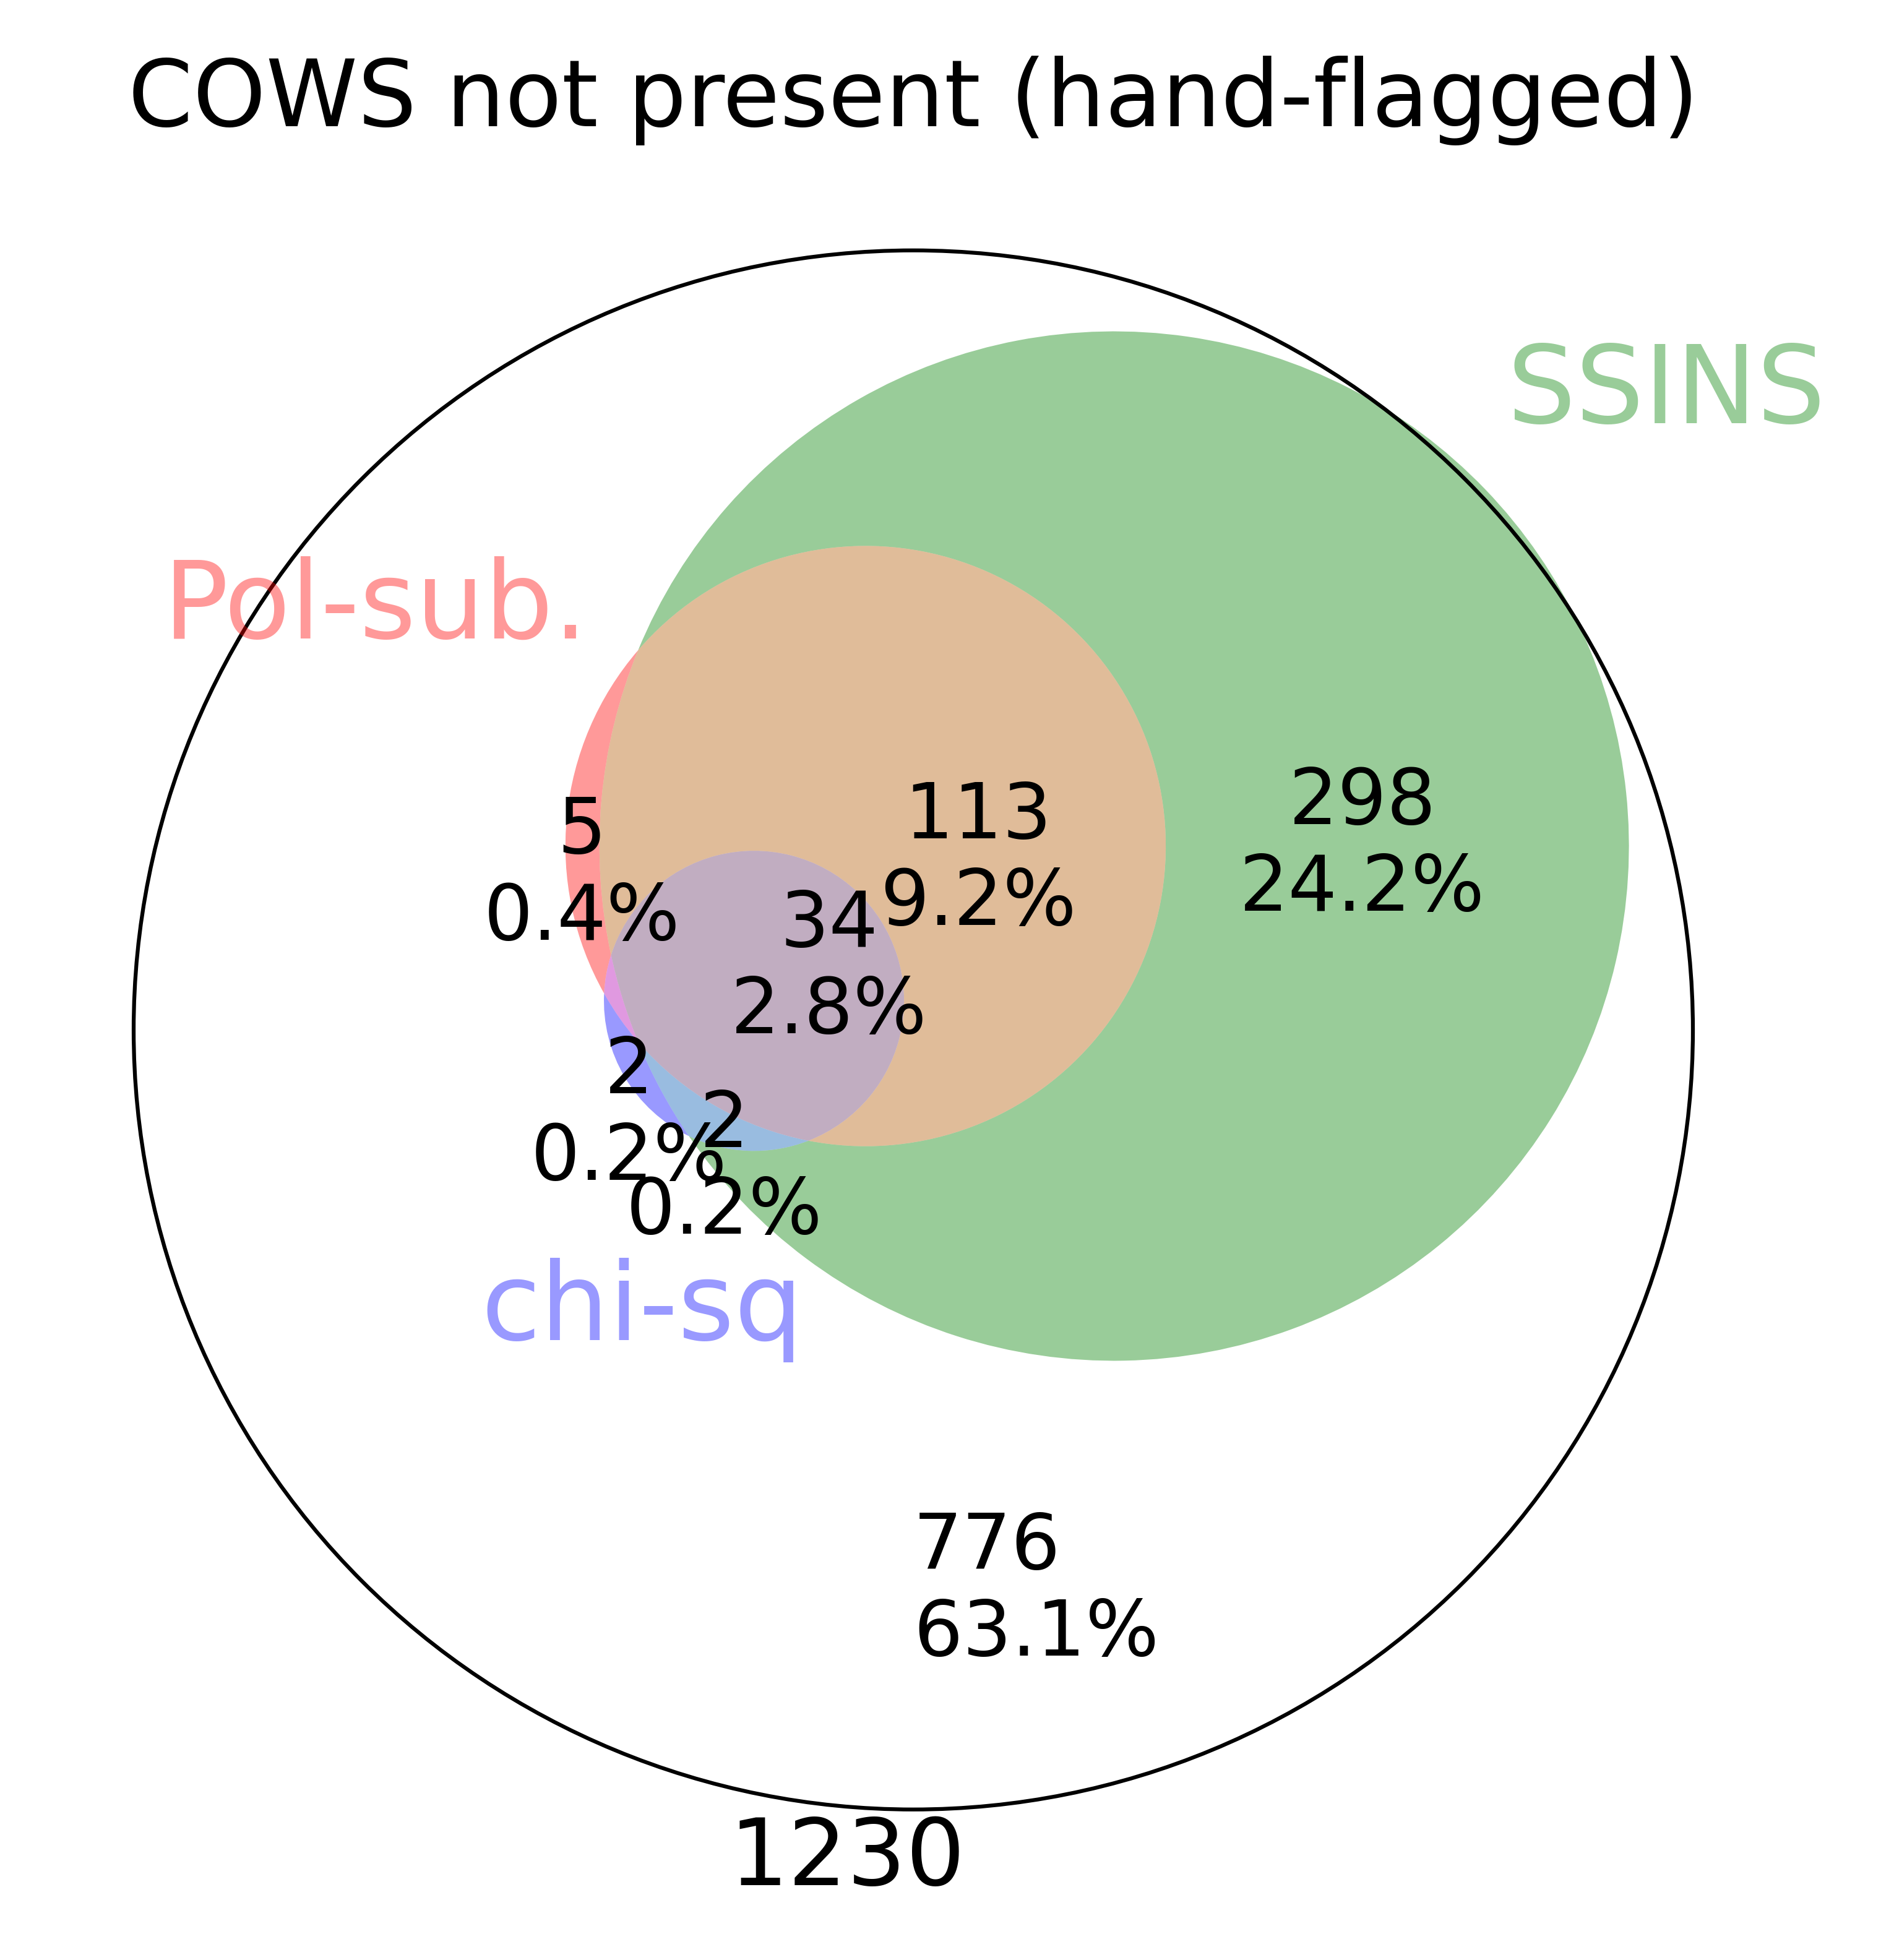

In [60]:
cows_df_local = copy.deepcopy(cows_df[cows_df['COWS']==False])
freq_range = 'TV7'
pol_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'pol_sub_flagged_{freq_range}']==True])
SSINS_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'better_SSINS_flagged_{freq_range}']==True])
chisq_set = set(cows_df_local['Obsid'][cows_df_local[f'CHISQ']==True])
total_union =len(pol_flagged_set.union(SSINS_flagged_set.union(chisq_set)))
grand_total = len(cows_df_local)
remaining = grand_total-total_union
plt.figure(figsize=(4,4),dpi=900)
out = matplotlib_venn.venn3([pol_flagged_set, SSINS_flagged_set, chisq_set], set_labels = ('Pol-sub.', 'SSINS', 'chi-sq'),
        subset_label_formatter=lambda x: percentage_formatter(x, grand_total))
number_label_size=10
for text in out.subset_labels:
    text.set_fontsize(number_label_size)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

center_x = (xlim[0] + xlim[1]) / 2
center_y = (ylim[0] + ylim[1]) / 2
radius = (max(xlim[1] - xlim[0], ylim[1] - ylim[0]) / 2 )* 1.25
center_adjust = (-.2,-.2)
circle = Circle((center_x+center_adjust[0], center_y+center_adjust[1]), radius, fill=False, color='black', linewidth=.5)
ax.add_patch(circle)
ax.set_xlim(center_x+center_adjust[0] - radius * 1.1, center_x+center_adjust[0] + radius * 1.1)
ax.set_ylim(center_y+center_adjust[1] - radius * 1.1, center_y+center_adjust[1] + radius * 1.1)


label_x = center_x -.2
label_y = center_y - radius * 0.9
ax.text(label_x, label_y, percentage_formatter(remaining,grand_total), fontsize=number_label_size, ha='left', va='center')

label_x = center_x -.4
label_y = center_y - radius * 1.3
ax.text(label_x, label_y, grand_total, fontsize=12, ha='left', va='center')


plt.title('COWS not present (hand-flagged)',size=12)
color_list = []
for i, id in enumerate(['100', '010', '001']):
    patch = out.get_patch_by_id(id)
    if patch:
        color_list.append(patch.get_facecolor())
        
for idx, label in enumerate(out.set_labels):
    circle_color = color_list[idx]
    label.set_color(circle_color)  # Set label color to match
    label.set_fontsize(14)  # You can change font too
    pos = label.get_position()
    new_pos = (pos[0]*1.4, pos[1]-.1)  # Move vertically up by 0.2 units
    label.set_position(new_pos)
    

len(pol_flagged_set)/len(cows_df_local)

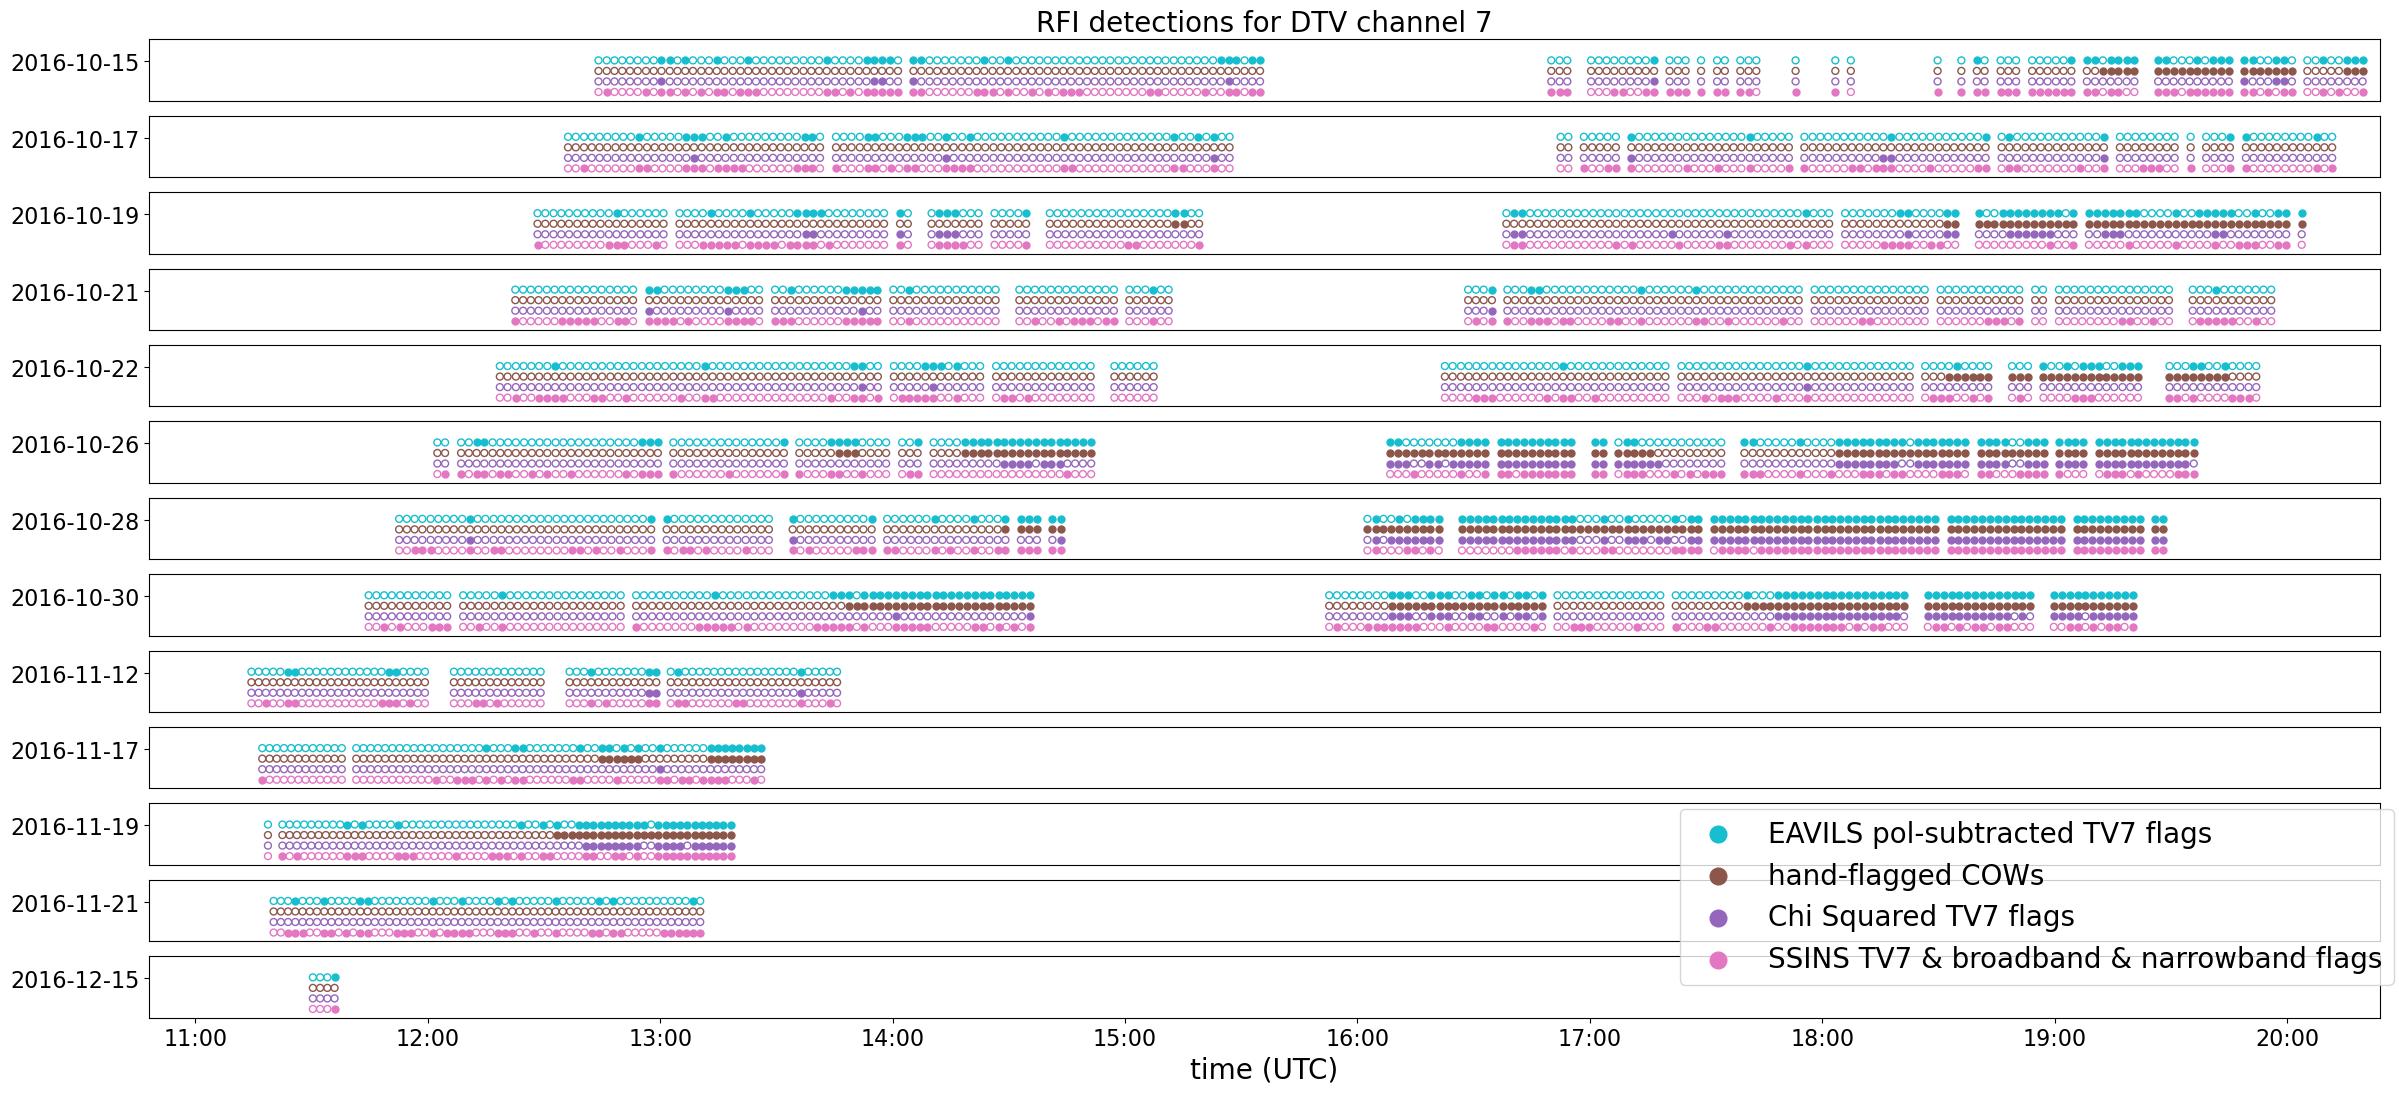

In [39]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*.85))



if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}

        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        pol_sub_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:cyan'}
        
        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'



        if cows_df.loc[:, "better_SSINS_flagged_TV7"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'


        if cows_df.loc[:, "pol_sub_flagged_TV7"][index]  == True: 
            pol_sub_tv7_kwargs['facecolors'] = 'tab:cyan'

        #if cows_df.loc[:, "SSINS_majority_flagged_TV7"][index] == True:
        #    pol_sub_tv7_kwargs['edgecolors']='none'
        spacing =.12
        kwarg_list = [pol_sub_tv7_kwargs,cows_kwargs,chisq_kwargs,ssins_tv7_kwargs]
        for ind,kwargs in enumerate(kwarg_list):
            ymod = (len(kwarg_list) - ind-1)*spacing
            ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + ymod, **kwargs, marker='o',s=25) 

        
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **pol_sub_tv7_kwargs) 
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **cows_kwargs) 
        
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **chisq_kwargs) # chisq

        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.0, **ssins_tv7_kwargs) # ssins tv7
    #ax[i].set_ylim(0.8, 1.7)
    ax[i].set_ylim(0.8, 1.5)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]],fontsize=16)
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times,fontsize=16)
plt.xlabel('time (UTC)', fontsize=20)

ax[0].set_title('RFI detections for DTV channel 7', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='hand-flagged COWs')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared TV7 flags')

#ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
#ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 & broadband & narrowband flags')
#ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

pol_sub_tv7_dot = ax[-1].scatter([], [], color='tab:cyan', marker='o', label='EAVILS pol-subtracted TV7 flags')

#filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
#empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[ pol_sub_tv7_dot,cows_dot, chisq_dot, ssins_tv7_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
fig.savefig("paper_plots/dotplot_updated.pdf")

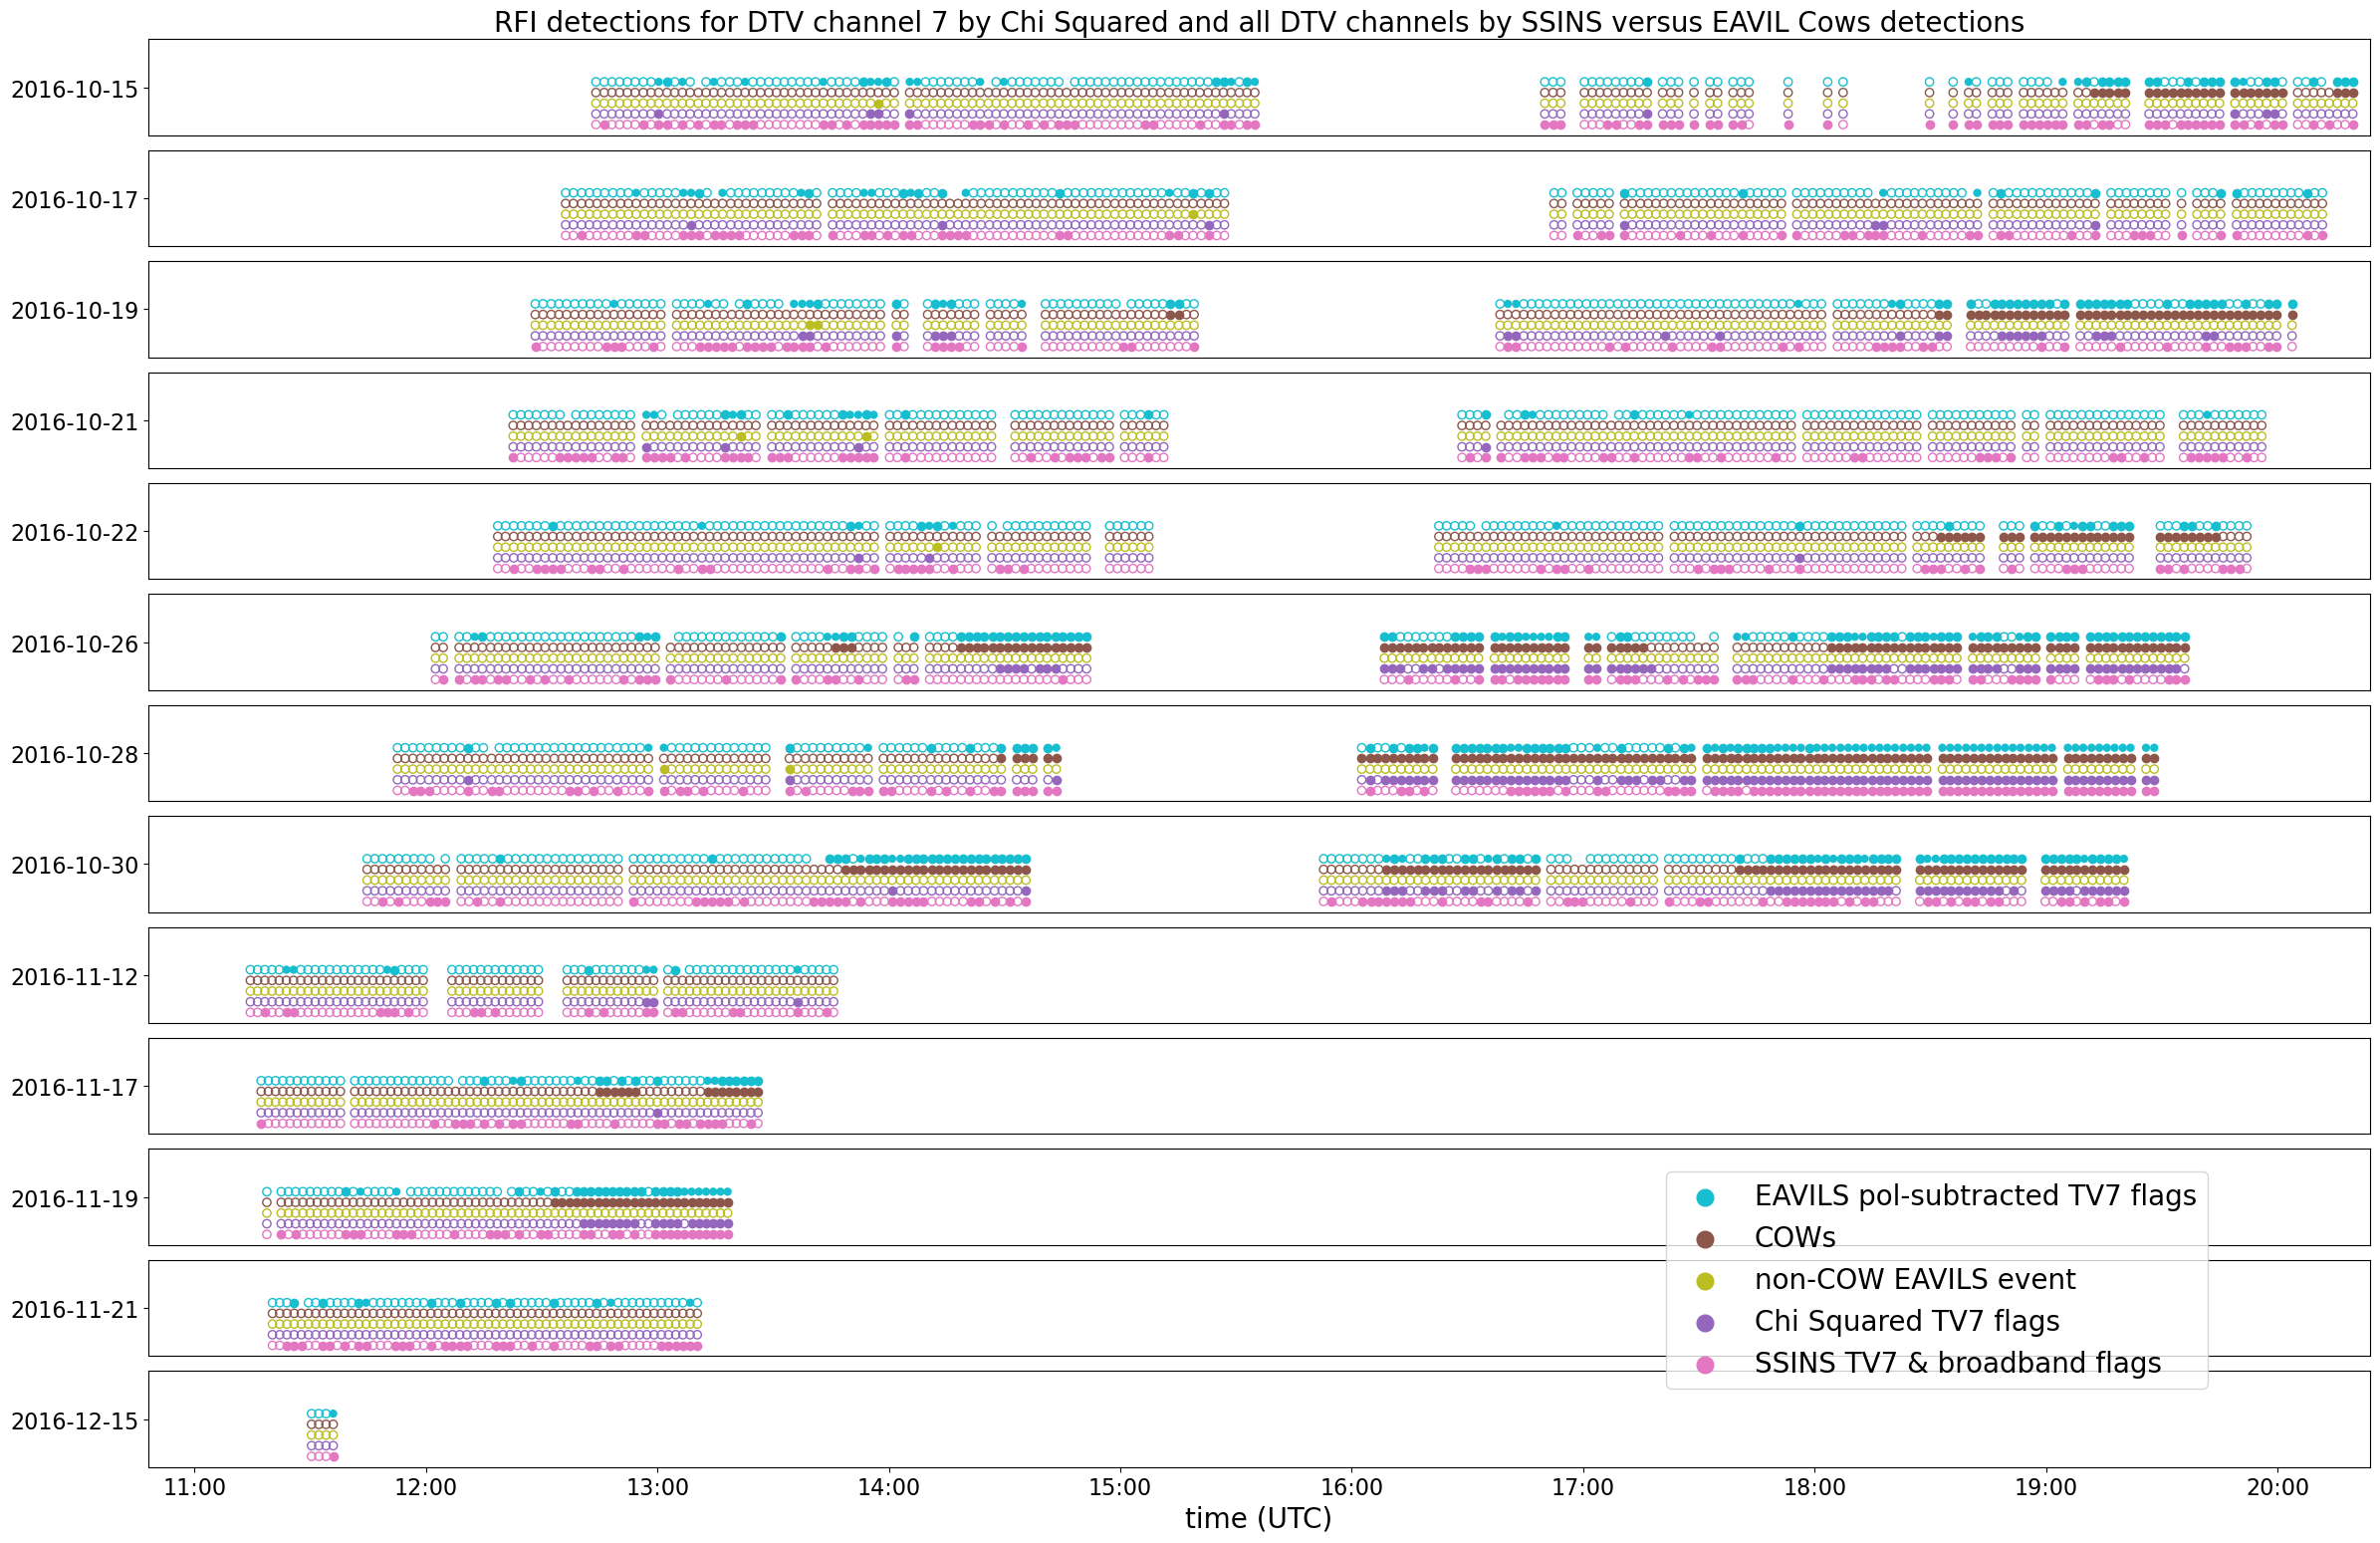

In [40]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*1.2))



if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}

        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        pol_sub_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:cyan'}
        
        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'



        if cows_df.loc[:, "better_SSINS_flagged_TV7"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'


        if cows_df.loc[:, "pol_sub_flagged_TV7"][index]  == True: 
            pol_sub_tv7_kwargs['facecolors'] = 'tab:cyan'

        if cows_df.loc[:, "SSINS_majority_flagged_TV7"][index] == True:
            pol_sub_tv7_kwargs['edgecolors']='none'

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.4, **pol_sub_tv7_kwargs) 
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **cows_kwargs) 
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **non_cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **chisq_kwargs) # chisq

        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **ssins_tv9_kwargs) # ssins tv9
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **ssins_tv8_kwargs) # ssins tv8
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.0, **ssins_tv7_kwargs) # ssins tv7
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y, **ssins_tv6_kwargs) # ssins tv6
    ax[i].set_ylim(0.8, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]],fontsize=16)
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times,fontsize=16)
plt.xlabel('time (UTC)', fontsize=20)

ax[0].set_title('RFI detections for DTV channel 7 by Chi Squared and all DTV channels by SSINS versus EAVIL Cows detections', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='COWs')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared TV7 flags')

#ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
#ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 & broadband flags')
#ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

pol_sub_tv7_dot = ax[-1].scatter([], [], color='tab:cyan', marker='o', label='EAVILS pol-subtracted TV7 flags')

#filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
#empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[ pol_sub_tv7_dot,cows_dot, non_cows_dot,chisq_dot, ssins_tv7_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
fig.savefig("paper_plots/dotplot_updated.pdf")

In [44]:
datafr= EAVILS_processing.add_pol_sub_stdv(datafr,estimated_pol_sub_stdv,threshold=threshold)

In [45]:
per_pointing_stats=EAVILS_processing.find_per_pointing_stats(datafr=datafr,shape_dict=shape_dict,list_titles=list_titles,threshold=threshold)


/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.1

In [54]:

importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/11-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('variance','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2),
                                  ('variance','YY','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               restricted_list=['1163593984','1163594096','1163594208','1163594320'],
                               line_plot_freq_ranges=['subTV','TV7']
                              )

pointing = 1
1163593984
1163594096
1163594208
1163594320
saving paper_plots/11-19-2016-EOR0_Tdim8_Fdim1restricted_ptng_1_EAVILS.pdf


In [55]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.22188136650874357,
  'TV6': 0.22404587649802482,
  'TV7': 0.2421911404588269,
  'TV8': 0.23445281335801796,
  'TV9': 0.3606226875035004},
 'EOR1': {'subTV': 0.32745058949911066,
  'TV6': 0.31758160951949477,
  'TV7': 0.33218929771625205,
  'TV8': 0.29784142456717105,
  'TV9': 0.4567150812528031}}

In [58]:


importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-19-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('variance','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2),
                                  ('variance','YY','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               restricted_list=['1160937608','1160937728','1160937848','1160937976']
                              )

pointing = 1
1160937608
1160937728
1160937848
1160937976
saving paper_plots/10-19-2016-EOR1_Tdim8_Fdim1restricted_ptng_1_EAVILS.pdf


In [49]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-17-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160758328
1160758448
1160758688
1160758816
1160758936
1160759056
1160759184
saving paper_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160759424
1160759544
1160759672
1160759792
1160759912
1160760032
1160760152
1160760280
1160760400
1160760520
1160760640
1160760768
1160760888
1160761008
1160761128
saving paper_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160761256
1160761376
1160761496
1160761616
1160761744
1160761864
1160762104
1160762232
1160762352
1160762472
1160762600
1160762720
1160762840
1160762960
saving paper_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160763088
1160763208
1160763328
1160763448
1160763576
1160763696
1160763816
1160763936
1160764056
1160764184
1160764304
1160764424
1160764544
1160764672
1160764792
1160764912
saving paper_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160765160
1160765280
1160765400
1160765528
1160765648
1160765768
1160765888
1160766016
1160766136
1160766256
1

/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/shape_base.py:65: UserWarning: Warning: converting a masked element to nan.
  ary = asanyarray(ary)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/ma/core.py:2359: UserWarning: Warning: converting a masked element to nan.
  a = np.array(a, copy=False, subok=True)
/Users/elillesk/repos/SSINS/EAVILS/EAVILS_processing.py:1142: UserWarning: Warning: converting a masked element to nan.
  shading_selection = vis_plt.pad_by(np.abs(plot_list)>=threshold,1)[:-1]


In [50]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-19-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160930288
1160930408
1160930536
1160930656
1160930776
1160930896
1160931016
1160931144
1160931264
1160931384
1160931504
saving paper_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160931632
1160931752
1160931872
1160931992
1160932120
1160932240
1160932360
1160932480
1160932608
1160932728
1160932848
1160932968
1160933096
1160933216
1160933336
1160933456
saving paper_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160933584
1160933704
1160933824
1160933944
1160934072
1160934192
1160934312
1160934440
1160934560
1160934680
1160934800
1160934928
1160935048
1160935168
1160935288
saving paper_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160935536
1160935656
1160935776
1160935896
1160936024
1160936144
1160936264
1160936384
1160936512
1160936632
1160936752
1160936872
1160937000
1160937120
1160937240
saving paper_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160937608
1160937728
1160937848
1160937976
1160938096
1

/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/shape_base.py:65: UserWarning: Warning: converting a masked element to nan.
  ary = asanyarray(ary)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/ma/core.py:2359: UserWarning: Warning: converting a masked element to nan.
  a = np.array(a, copy=False, subok=True)
/Users/elillesk/repos/SSINS/EAVILS/EAVILS_processing.py:1142: UserWarning: Warning: converting a masked element to nan.
  shading_selection = vis_plt.pad_by(np.abs(plot_list)>=threshold,1)[:-1]


In [51]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-26-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161518528
1161518648
1161518896
1161519016
1161519136
1161519256
1161519384
1161519504
1161519624
1161519744
1161519872
1161519992
1161520112
1161520232
1161520360
saving paper_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161520480
1161520600
1161520720
1161520848
1161520968
1161521088
1161521208
1161521336
1161521456
1161521576
1161521696
1161521824
1161521944
1161522184
1161522312
saving paper_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161522432
1161522552
1161522672
1161522800
1161522920
1161523040
1161523160
1161523288
1161523408
1161523528
1161523648
1161523776
1161523896
1161524136
saving paper_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161524264
1161524384
1161524504
1161524624
1161524752
1161524872
1161524992
1161525112
1161525240
1161525360
1161525480
1161525728
1161525848
1161525968
saving paper_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161526216
1161526336
1161526456
1161526576
1

/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/shape_base.py:65: UserWarning: Warning: converting a masked element to nan.
  ary = asanyarray(ary)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/ma/core.py:2359: UserWarning: Warning: converting a masked element to nan.
  a = np.array(a, copy=False, subok=True)
/Users/elillesk/repos/SSINS/EAVILS/EAVILS_processing.py:1142: UserWarning: Warning: converting a masked element to nan.
  shading_selection = vis_plt.pad_by(np.abs(plot_list)>=threshold,1)[:-1]


In [52]:
# importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-28-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False
                              )


pointing = -3
1161705736
1161705864
1161705984
1161706104
1161706224
1161706352
1161706472
1161706592
1161706712
1161706840
1161706960
saving paper_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161707200
1161707328
1161707448
1161707568
1161707688
1161707816
1161707936
1161708056
1161708176
1161708304
1161708424
1161708544
1161708664
1161708792
1161708912
saving paper_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161709032
1161709152
1161709280
1161709400
1161709520
1161709640
1161709768
1161709888
1161710008
1161710128
1161710256
1161710376
1161710496
1161710616
1161710744
saving paper_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161710864
1161711104
1161711232
1161711352
1161711472
1161711592
1161711720
1161711840
1161711960
1161712080
1161712208
1161712328
1161712448
1161712568
1161712696
saving paper_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161712816
1161712936
1161713056
1161713184
1161713304
1161713424
1

In [53]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/11-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='paper_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False
                              )


pointing = -2
1163589504
1163589728
1163589840
1163589952
1163590064
1163590176
1163590288
saving paper_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1163590400
1163590512
1163590624
1163590736
1163590848
1163590960
1163591072
1163591184
1163591296
1163591408
1163591520
1163591632
1163591744
1163591856
1163591968
1163592080
saving paper_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1163592192
1163592304
1163592416
1163592528
1163592640
1163592752
1163592864
1163592976
1163593088
1163593200
1163593312
1163593424
1163593536
1163593648
1163593760
1163593872
saving paper_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1163593984
1163594096
1163594208
1163594320
1163594432
1163594544
1163594656
1163594768
1163594880
1163594992
1163595104
1163595216
1163595328
1163595440
1163595552
1163595664
1163595776
saving paper_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_1_EAVILS.pdf
pointing = 2
1163595888
1163596000
1163596112
1163596224
1163596336
1163596448
116

In [715]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == True & CHISQ == False')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160580264', '10-15-2016-EOR0', 2),
 ('1160748440', '10-17-2016-EOR0', -1),
 ('1160752712', '10-17-2016-EOR0', 2),
 ('1160919672', '10-19-2016-EOR0', -1),
 ('1161180728', '10-22-2016-EOR0', 0)]

In [689]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False &  pol_sub_flagged_no_SSINS_{freq_range} == True')['Obsid'])
auto_list = sorted([(obs,source_list_dict[obs],info['pointing'],'auto') for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])
weird_obs = list(cows_df[cows_df['non cow EAVILS event ']==True]['Obsid'])
hand_list = sorted([(obs,source_list_dict[obs],info['pointing'],'hand') for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])
comb_list = sorted(auto_list+hand_list)
comb_list

[('1160575016', '10-15-2016-EOR0', -1, 'hand'),
 ('1160575136', '10-15-2016-EOR0', -1, 'auto'),
 ('1160580264', '10-15-2016-EOR0', 2, 'auto'),
 ('1160580384', '10-15-2016-EOR0', 2, 'auto'),
 ('1160593808', '10-15-2016-EOR1', 1, 'auto'),
 ('1160748440', '10-17-2016-EOR0', -1, 'auto'),
 ('1160752712', '10-17-2016-EOR0', 2, 'auto'),
 ('1160752712', '10-17-2016-EOR0', 2, 'hand'),
 ('1160919552', '10-19-2016-EOR0', -1, 'hand'),
 ('1160919672', '10-19-2016-EOR0', -1, 'auto'),
 ('1160919672', '10-19-2016-EOR0', -1, 'hand'),
 ('1160921752', '10-19-2016-EOR0', 0, 'auto'),
 ('1161091272', '10-21-2016-EOR0', -2, 'auto'),
 ('1161091272', '10-21-2016-EOR0', -2, 'hand'),
 ('1161092856', '10-21-2016-EOR0', -1, 'auto'),
 ('1161093224', '10-21-2016-EOR0', -1, 'hand'),
 ('1161180728', '10-22-2016-EOR0', 0, 'auto'),
 ('1161180728', '10-22-2016-EOR0', 0, 'hand'),
 ('1161521944', '10-26-2016-EOR0', -2, 'auto'),
 ('1161694880', '10-28-2016-EOR0', -1, 'hand'),
 ('1161696832', '10-28-2016-EOR0', 0, 'auto'),
 

In [675]:


freq_range = 'TV7'
weird_obs = list(cows_df[cows_df['non cow EAVILS event ']==True]['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160575016', '10-15-2016-EOR0', -1),
 ('1160752712', '10-17-2016-EOR0', 2),
 ('1160919552', '10-19-2016-EOR0', -1),
 ('1160919672', '10-19-2016-EOR0', -1),
 ('1161091272', '10-21-2016-EOR0', -2),
 ('1161093224', '10-21-2016-EOR0', -1),
 ('1161180728', '10-22-2016-EOR0', 0),
 ('1161694880', '10-28-2016-EOR0', -1),
 ('1161696832', '10-28-2016-EOR0', 0)]

In [719]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==True & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == False & CHISQ == True')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1161533536', '10-26-2016-EOR1', -3),
 ('1161533896', '10-26-2016-EOR1', -3),
 ('1161534024', '10-26-2016-EOR1', -3),
 ('1161534264', '10-26-2016-EOR1', -3),
 ('1161536824', '10-26-2016-EOR1', -1),
 ('1161537312', '10-26-2016-EOR1', -1),
 ('1161706104', '10-28-2016-EOR1', -3),
 ('1161709888', '10-28-2016-EOR1', -1),
 ('1161710008', '10-28-2016-EOR1', -1),
 ('1161710256', '10-28-2016-EOR1', -1),
 ('1161710376', '10-28-2016-EOR1', -1)]

In [720]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == False & CHISQ == True')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160932848', '10-19-2016-EOR1', -2), ('1161537440', '10-26-2016-EOR1', -1)]